# Phase C — Linear vs LightGBM and Feature-Family Ablation

This notebook reads the saved Phase C CSV outputs. It does not retrain models.
The final 20% exploratory holdout remains unused.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

current_directory = Path.cwd()
project_root = current_directory.parent if current_directory.name == "notebooks" else current_directory
reports_directory = project_root / "reports" / "tables"

model_summary = pd.read_csv(reports_directory / "phase_c_model_summary.csv")
ablation_summary = pd.read_csv(reports_directory / "phase_c_ablation_summary.csv")
importance_summary = pd.read_csv(
    reports_directory / "phase_c_feature_importance_summary.csv"
)

pd.set_option("display.max_columns", 200)
model_summary


,horizon,train_start_mean,train_start_std,train_start_min,train_start_max,train_end_mean,train_end_std,train_end_min,train_end_max,validation_start_mean,validation_start_std,validation_start_min,validation_start_max,validation_end_mean,validation_end_std,validation_end_min,validation_end_max,train_rows_mean,train_rows_std,train_rows_min,train_rows_max,validation_rows_mean,validation_rows_std,validation_rows_min,validation_rows_max,purge_events_mean,purge_events_std,purge_events_min,purge_events_max,development_end_exclusive_mean,development_end_exclusive_std,development_end_exclusive_min,development_end_exclusive_max,train_rows_after_target_filter_mean,train_rows_after_target_filter_std,train_rows_after_target_filter_min,train_rows_after_target_filter_max,validation_rows_after_target_filter_mean,validation_rows_after_target_filter_std,validation_rows_after_target_filter_min,validation_rows_after_target_filter_max,train_time_start_seconds_mean,train_time_start_seconds_std,train_time_start_seconds_min,train_time_start_seconds_max,train_time_end_seconds_mean,train_time_end_seconds_std,train_time_end_seconds_min,train_time_end_seconds_max,validation_time_start_seconds_mean,validation_time_start_seconds_std,validation_time_start_seconds_min,validation_time_start_seconds_max,validation_time_end_seconds_mean,validation_time_end_seconds_std,validation_time_end_seconds_min,validation_time_end_seconds_max,logistic_balanced_accuracy_mean,logistic_balanced_accuracy_std,logistic_balanced_accuracy_min,logistic_balanced_accuracy_max,lightgbm_balanced_accuracy_mean,lightgbm_balanced_accuracy_std,lightgbm_balanced_accuracy_min,lightgbm_balanced_accuracy_max,lightgbm_balanced_accuracy_delta_mean,lightgbm_balanced_accuracy_delta_std,lightgbm_balanced_accuracy_delta_min,lightgbm_balanced_accuracy_delta_max,logistic_macro_f1_mean,logistic_macro_f1_std,logistic_macro_f1_min,logistic_macro_f1_max,lightgbm_macro_f1_mean,lightgbm_macro_f1_std,lightgbm_macro_f1_min,lightgbm_macro_f1_max,lightgbm_macro_f1_delta_mean,lightgbm_macro_f1_delta_std,lightgbm_macro_f1_delta_min,lightgbm_macro_f1_delta_max,zero_mae_bps_mean,zero_mae_bps_std,zero_mae_bps_min,zero_mae_bps_max,ridge_mae_bps_mean,ridge_mae_bps_std,ridge_mae_bps_min,ridge_mae_bps_max,lightgbm_mae_bps_mean,lightgbm_mae_bps_std,lightgbm_mae_bps_min,lightgbm_mae_bps_max,ridge_mae_improvement_pct_mean,ridge_mae_improvement_pct_std,ridge_mae_improvement_pct_min,ridge_mae_improvement_pct_max,lightgbm_mae_improvement_pct_mean,lightgbm_mae_improvement_pct_std,lightgbm_mae_improvement_pct_min,lightgbm_mae_improvement_pct_max,lightgbm_mae_delta_vs_ridge_bps_mean,lightgbm_mae_delta_vs_ridge_bps_std,lightgbm_mae_delta_vs_ridge_bps_min,lightgbm_mae_delta_vs_ridge_bps_max,ridge_rmse_bps_mean,ridge_rmse_bps_std,ridge_rmse_bps_min,ridge_rmse_bps_max,lightgbm_rmse_bps_mean,lightgbm_rmse_bps_std,lightgbm_rmse_bps_min,lightgbm_rmse_bps_max,ridge_rank_ic_mean,ridge_rank_ic_std,ridge_rank_ic_min,ridge_rank_ic_max,lightgbm_rank_ic_mean,lightgbm_rank_ic_std,lightgbm_rank_ic_min,lightgbm_rank_ic_max,lightgbm_rank_ic_delta_mean,lightgbm_rank_ic_delta_std,lightgbm_rank_ic_delta_min,lightgbm_rank_ic_delta_max,ridge_nonzero_directional_accuracy_mean,ridge_nonzero_directional_accuracy_std,ridge_nonzero_directional_accuracy_min,ridge_nonzero_directional_accuracy_max,lightgbm_nonzero_directional_accuracy_mean,lightgbm_nonzero_directional_accuracy_std,lightgbm_nonzero_directional_accuracy_min,lightgbm_nonzero_directional_accuracy_max,logistic_active_signal_fraction_mean,logistic_active_signal_fraction_std,logistic_active_signal_fraction_min,logistic_active_signal_fraction_max,lightgbm_active_signal_fraction_mean,lightgbm_active_signal_fraction_std,lightgbm_active_signal_fraction_min,lightgbm_active_signal_fraction_max,logistic_mean_gross_active_bps_mean,logistic_mean_gross_active_bps_std,logistic_mean_gross_active_bps_min,logistic_mean_gross_active_bps_max,lightgbm_mean_gross_active_bps_mean,lightgbm_mean_gross_active_bps_std,ligh

## 1. Classification comparison

Balanced accuracy and macro F1 are preferred to raw accuracy because the flat class changes materially by horizon.


In [2]:
classification = model_summary.set_index("horizon")[[
    "logistic_balanced_accuracy_mean",
    "lightgbm_balanced_accuracy_mean",
    "logistic_macro_f1_mean",
    "lightgbm_macro_f1_mean",
]]
classification


,logistic_balanced_accuracy_mean,lightgbm_balanced_accuracy_mean,logistic_macro_f1_mean,lightgbm_macro_f1_mean
horizon,,,,
10,0.365568,0.437792,0.292905,0.434949
50,0.378998,0.412575,0.289831,0.386776
100,0.349722,0.370090,0.255289,0.335643


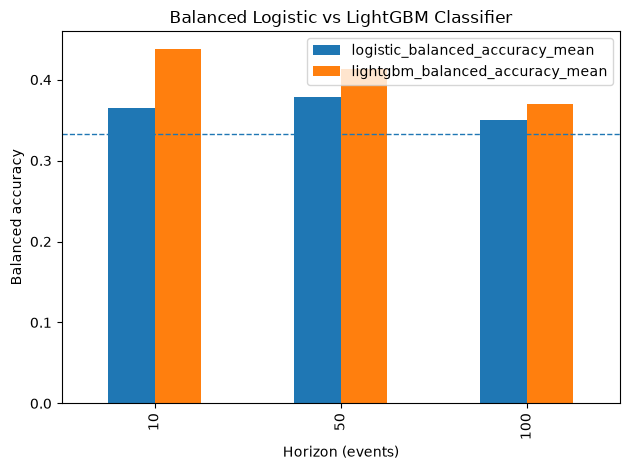

In [3]:
classification[[
    "logistic_balanced_accuracy_mean",
    "lightgbm_balanced_accuracy_mean",
]].plot(kind="bar")
plt.axhline(1 / 3, linestyle="--", linewidth=1)
plt.ylabel("Balanced accuracy")
plt.xlabel("Horizon (events)")
plt.title("Balanced Logistic vs LightGBM Classifier")
plt.tight_layout()
plt.show()


## 2. Regression comparison

Positive MAE improvement means the model beats the zero-return predictor. Rank IC measures ordering rather than magnitude calibration.


In [4]:
regression = model_summary.set_index("horizon")[[
    "ridge_mae_improvement_pct_mean",
    "lightgbm_mae_improvement_pct_mean",
    "ridge_rank_ic_mean",
    "lightgbm_rank_ic_mean",
    "ridge_nonzero_directional_accuracy_mean",
    "lightgbm_nonzero_directional_accuracy_mean",
]]
regression


,ridge_mae_improvement_pct_mean,lightgbm_mae_improvement_pct_mean,ridge_rank_ic_mean,lightgbm_rank_ic_mean,ridge_nonzero_directional_accuracy_mean,lightgbm_nonzero_directional_accuracy_mean
horizon,,,,,,
10,-5.925138,0.527553,0.198175,0.229011,0.601221,0.609749
50,-0.064534,0.506651,0.211135,0.266265,0.570636,0.582704
100,-3.095868,-2.517956,0.164012,0.211111,0.540337,0.545151


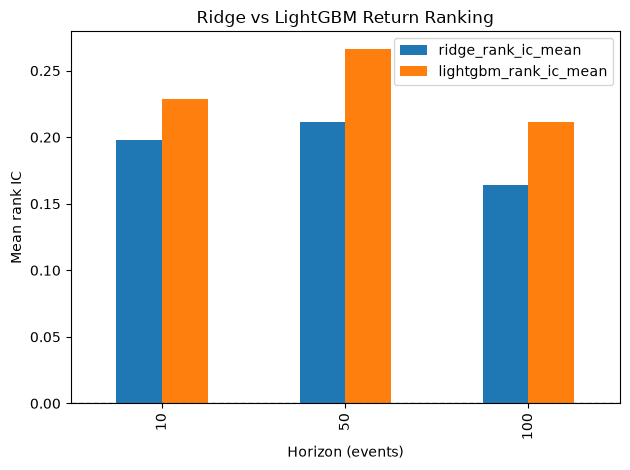

In [5]:
regression[["ridge_rank_ic_mean", "lightgbm_rank_ic_mean"]].plot(kind="bar")
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Mean rank IC")
plt.xlabel("Horizon (events)")
plt.title("Ridge vs LightGBM Return Ranking")
plt.tight_layout()
plt.show()


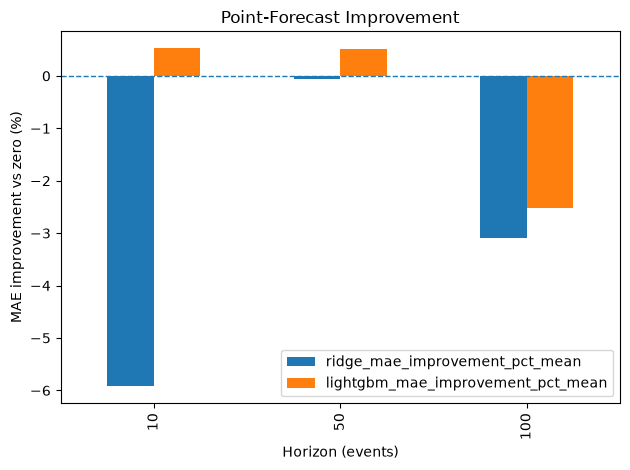

In [6]:
regression[[
    "ridge_mae_improvement_pct_mean",
    "lightgbm_mae_improvement_pct_mean",
]].plot(kind="bar")
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("MAE improvement vs zero (%)")
plt.xlabel("Horizon (events)")
plt.title("Point-Forecast Improvement")
plt.tight_layout()
plt.show()


## 3. Economic comparison at the fixed 0.10 threshold

The same threshold is used for both classifiers. Because probability calibration may differ, activity must be interpreted alongside gross edge and break-even cost.


In [7]:
economics = model_summary.set_index("horizon")[[
    "logistic_active_signal_fraction_mean",
    "lightgbm_active_signal_fraction_mean",
    "logistic_mean_gross_active_bps_mean",
    "lightgbm_mean_gross_active_bps_mean",
    "logistic_mean_net_active_bps_mean",
    "lightgbm_mean_net_active_bps_mean",
    "logistic_break_even_cost_fraction_mean",
    "lightgbm_break_even_cost_fraction_mean",
]]
economics


,logistic_active_signal_fraction_mean,lightgbm_active_signal_fraction_mean,logistic_mean_gross_active_bps_mean,lightgbm_mean_gross_active_bps_mean,logistic_mean_net_active_bps_mean,lightgbm_mean_net_active_bps_mean,logistic_break_even_cost_fraction_mean,lightgbm_break_even_cost_fraction_mean
horizon,,,,,,,,
10,0.415684,0.597203,0.087062,0.106849,-2.351522,-2.414724,0.036914,0.042651
50,0.478901,0.701124,0.213715,0.182020,-2.353640,-2.394170,0.087019,0.072256
100,0.503741,0.709227,0.252229,0.179378,-2.271547,-2.381711,0.107587,0.076052


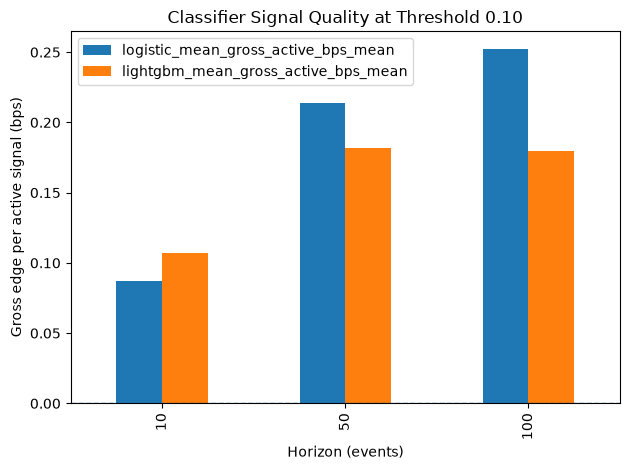

In [8]:
economics[[
    "logistic_mean_gross_active_bps_mean",
    "lightgbm_mean_gross_active_bps_mean",
]].plot(kind="bar")
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Gross edge per active signal (bps)")
plt.xlabel("Horizon (events)")
plt.title("Classifier Signal Quality at Threshold 0.10")
plt.tight_layout()
plt.show()


## 4. Fifty-event feature-family ablation

Each ablation removes one complete family from the LightGBM models. Compare every row with `all_features`; a drop after removal indicates that the family contributes useful information.


In [9]:
ablation_columns = [
    "feature_set",
    "feature_count_mean",
    "balanced_accuracy_mean",
    "macro_f1_mean",
    "mae_improvement_pct_mean",
    "rank_ic_mean",
    "nonzero_directional_accuracy_mean",
    "mean_gross_return_active_bps_mean",
    "break_even_cost_fraction_mean",
]
ablation_summary[ablation_columns].sort_values("rank_ic_mean", ascending=False)


,feature_set,feature_count_mean,balanced_accuracy_mean,macro_f1_mean,mae_improvement_pct_mean,rank_ic_mean,nonzero_directional_accuracy_mean,mean_gross_return_active_bps_mean,break_even_cost_fraction_mean
3,without_time,31.0,0.438860,0.420945,3.511129,0.275400,0.604996,0.270734,0.106516
0,all_features,35.0,0.412575,0.386776,0.506651,0.266265,0.582704,0.182020,0.072256
1,without_book_state,29.0,0.412345,0.391831,0.334253,0.256869,0.582464,0.190358,0.076727
4,without_volatility,32.0,0.408802,0.383367,-0.206117,0.253608,0.578202,0.169652,0.067311
2,without_event_flow,13.0,0.356755,0.280477,-6.436416,0.048156,0.493672,0.010448,0.004530


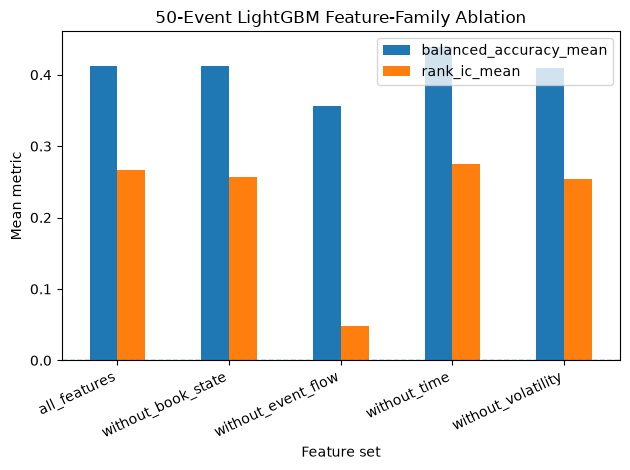

In [10]:
ablation_plot = ablation_summary.set_index("feature_set")[[
    "balanced_accuracy_mean",
    "rank_ic_mean",
]]
ablation_plot.plot(kind="bar")
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Mean metric")
plt.xlabel("Feature set")
plt.title("50-Event LightGBM Feature-Family Ablation")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 5. Gain importance at the primary horizon

Gain importance is descriptive, not causal. Correlated features can share or substitute importance, so interpret it together with the family ablation.


In [11]:
primary_importance = importance_summary.loc[
    importance_summary["horizon"].eq(50)
].copy()

for model_name in ["lightgbm_classifier", "lightgbm_regressor"]:
    display(
        primary_importance.loc[primary_importance["model"].eq(model_name)]
        .nlargest(15, "mean")[["model", "feature", "mean", "std"]]
    )


,model,feature,mean,std
70,lightgbm_classifier,spread_bps,0.081481,0.004170
71,lightgbm_classifier,rolling_volatility_50,0.080522,0.019172
72,lightgbm_classifier,trade_pressure_50,0.073416,0.007914
73,lightgbm_classifier,trade_pressure_20,0.067920,0.007131
74,lightgbm_classifier,rolling_volatility_100,0.055111,0.007443
75,lightgbm_classifier,seconds_from_open,0.051852,0.010618
76,lightgbm_classifier,time_sin,0.044008,0.017710
77,lightgbm_classifier,rolling_volatility_20,0.042798,0.009356
78,lightgbm_classifier,time_cos,0.041387,0.006781
79,lightgbm_classifier,ofi_l1_sum_100,0.040502,0.001963


,model,feature,mean,std
105,lightgbm_regressor,trade_pressure_20,0.142927,0.024405
106,lightgbm_regressor,trade_pressure_50,0.098463,0.021355
107,lightgbm_regressor,rolling_volatility_100,0.093698,0.035128
108,lightgbm_regressor,spread_bps,0.071271,0.010710
109,lightgbm_regressor,seconds_from_open,0.058108,0.020256
110,lightgbm_regressor,time_sin,0.050368,0.016111
111,lightgbm_regressor,ofi_l1_sum_100,0.040191,0.006783
112,lightgbm_regressor,rolling_volatility_50,0.040174,0.005526
113,lightgbm_regressor,ofi_l1_sum_50,0.039314,0.006307
114,lightgbm_regressor,time_cos,0.039022,0.008431


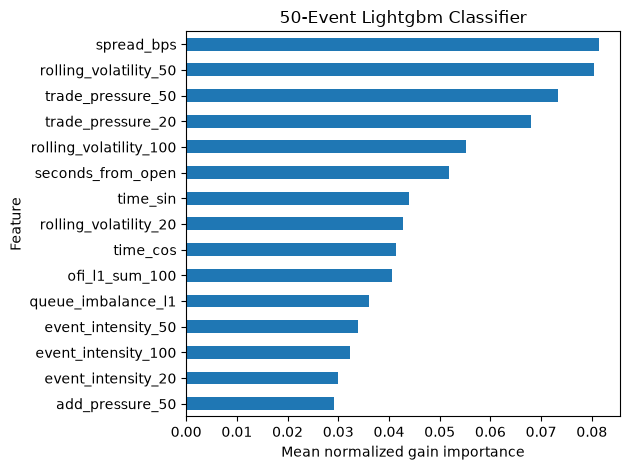

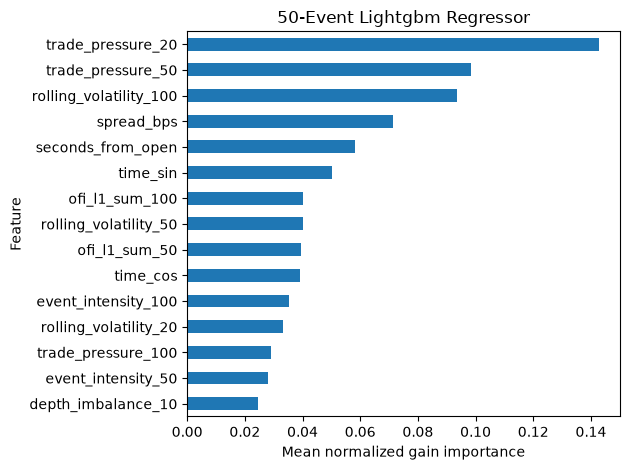

In [12]:
for model_name in ["lightgbm_classifier", "lightgbm_regressor"]:
    top = (
        primary_importance.loc[primary_importance["model"].eq(model_name)]
        .nlargest(15, "mean")
        .sort_values("mean")
    )
    top.plot(x="feature", y="mean", kind="barh", legend=False)
    plt.xlabel("Mean normalized gain importance")
    plt.ylabel("Feature")
    plt.title(f"50-Event {model_name.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()


## Review checklist

Before selecting LightGBM for the final research report, verify:

1. It improves the target metric in most folds, not only on average.
2. Any MAE gain is measured against the zero-return predictor.
3. Rank IC and directional gains do not come with unstable activity.
4. Feature-family removal produces interpretable, repeated changes.
5. Economic results remain reported after quoted-spread costs.
6. The final exploratory holdout is still untouched.
